In [10]:
import numpy as np 
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
df = pd.read_csv(r"C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\dataset_1.csv")
df

,x,y
0,0.064127,2.563397
1,0.075539,2.542556
2,0.279003,2.049602
3,0.477151,1.579005
4,0.516348,1.647343
5,0.536789,1.486094
6,0.616411,1.480647
7,0.637491,1.554980
8,0.646369,1.392967
9,0.693635,1.323829


In [5]:
X = df.select_dtypes(include=['number'])
k = 3 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

In [6]:
print("Clustered Dataset:")
print(df.head())

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

Clustered Dataset:
          x         y  Cluster
0  0.064127  2.563397        0
1  0.075539  2.542556        0
2  0.279003  2.049602        0
3  0.477151  1.579005        0
4  0.516348  1.647343        0

Cluster Centers:
[[0.45428619 1.76204198]
 [2.05834248 0.37551139]
 [1.20016634 0.84782613]]


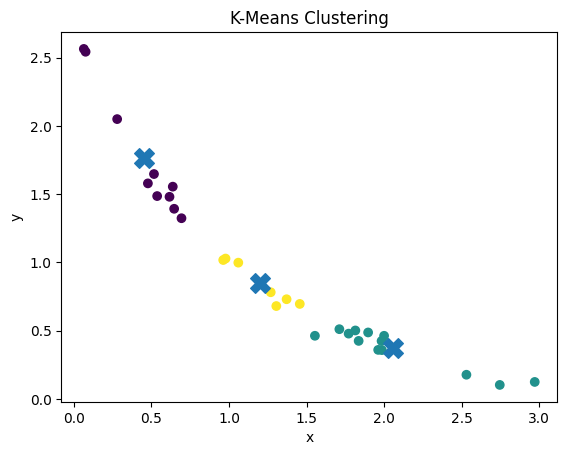

In [7]:
plt.scatter(df['x'], df['y'], c=df['Cluster'])
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.xlabel("x")
plt.ylabel("y")
plt.title("K-Means Clustering")
plt.show()

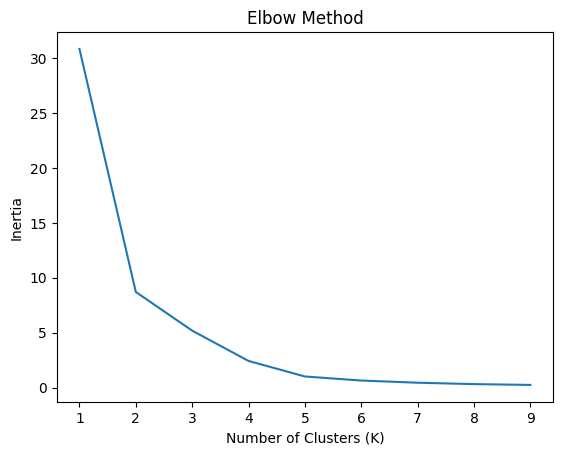

In [8]:
inertia = []

K_range = range(1, 10)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [11]:
# 4. Create Interactive Scatter Plot
fig = px.scatter(
    df,
    x='x',
    y='y',
    color=df['Cluster'].astype(str),
    title="K-Means Clustering (Interactive)",
    labels={'color': 'Cluster'},
)

# 5. Add Cluster Centers
centers = kmeans.cluster_centers_
fig.add_scatter(
    x=centers[:, 0],
    y=centers[:, 1],
    mode='markers',
    marker=dict(size=12, symbol='x'),
    name='Centroids'
)

# 6. Show Plot
fig.show()

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\plotly\express\_core.py:1992: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])
